In [9]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler , LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score , classification_report , confusion_matrix
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense , Conv2D , Flatten , MaxPooling2D , Dropout
from tensorflow.keras.utils import to_categorical
import warnings
warnings.filterwarnings('ignore')

In [29]:
# import dataset
from keras.datasets import mnist
# load dataset
(x_train, y_train),(x_test, y_test) = mnist.load_data()
# count the number of unique train labels
unique, counts = np.unique(y_train, return_counts=True)
print("Train labels: ", dict(zip(unique, counts)))
# count the number of unique test labels
unique, counts = np.unique(y_test, return_counts=True)
print("\nTest labels: ", dict(zip(unique, counts)))


11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
Train labels:  {np.uint8(0): np.int64(5923), np.uint8(1): np.int64(6742), np.uint8(2): np.int64(5958), np.uint8(3): np.int64(6131), np.uint8(4): np.int64(5842), np.uint8(5): np.int64(5421), np.uint8(6): np.int64(5918), np.uint8(7): np.int64(6265), np.uint8(8): np.int64(5851), np.uint8(9): np.int64(5949)}

Test labels:  {np.uint8(0): np.int64(980), np.uint8(1): np.int64(1135), np.uint8(2): np.int64(1032), np.uint8(3): np.int64(1010), np.uint8(4): np.int64(982), np.uint8(5): np.int64(892), np.uint8(6): np.int64(958), np.uint8(7): np.int64(1028), np.uint8(8): np.int64(974), np.uint8(9): np.int64(1009)}


In [30]:
x_train_img = x_train.reshape(-1,28,28)
x_test_img = x_test.reshape(-1,28,28)

In [33]:
y_train_cat = to_categorical(y_train,10)
y_test_cat = to_categorical(y_test,10)

In [34]:
perceptron = Sequential([
    Flatten(input_shape=(28,28)),
    Dense(10,activation='softmax')
])

In [35]:
perceptron.compile(optimizer='sgd',loss='categorical_crossentropy',metrics=['accuracy'])

In [36]:
# Training
history_perc = perceptron.fit(x_train_img,y_train_cat,epochs=5,batch_size=32,validation_data=(x_test_img,y_test_cat),verbose=1)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 9s 4ms/step - accuracy: 0.8411 - loss: 320.0311 - val_accuracy: 0.9037 - val_loss: 194.0505
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.8670 - loss: 263.4211 - val_accuracy: 0.8899 - val_loss: 226.3714
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8743 - loss: 251.4025 - val_accuracy: 0.8466 - val_loss: 311.2672
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.8747 - loss: 250.7027 - val_accuracy: 0.8774 - val_loss: 265.8424
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 7s 3ms/step - accuracy: 0.8781 - loss: 240.1645 - val_accuracy: 0.8798 - val_loss: 239.1702


In [39]:
acc_perc = perceptron.evaluate(x_test_img,y_test_cat,verbose=0)[1]
acc_perc

0.879800021648407

In [41]:
# ANN 785x128x64x10
ann = Sequential([
    Flatten(input_shape=(28,28)),
    Dense(128,activation='relu'),
    Dense(64,activation='relu'),
    Dense(10,activation='softmax')
])

In [42]:
ann.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])

In [43]:
history_ann = ann.fit(x_train_img,y_train_cat,epochs=5,batch_size=32,validation_data=(x_test_img,y_test_cat),verbose=1)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 13s 6ms/step - accuracy: 0.8167 - loss: 1.5301 - val_accuracy: 0.8923 - val_loss: 0.3975
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9174 - loss: 0.3127 - val_accuracy: 0.9306 - val_loss: 0.2804
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9389 - loss: 0.2228 - val_accuracy: 0.9319 - val_loss: 0.2550
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9518 - loss: 0.1734 - val_accuracy: 0.9571 - val_loss: 0.1552
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.9587 - loss: 0.1482 - val_accuracy: 0.9584 - val_loss: 0.1595


In [74]:
acc_ann = ann.evaluate(x_test_img,y_test_cat,verbose=0)[1]
acc_ann

0.9584000110626221

In [56]:
# Reshape for CNN
x_train_cnn = x_train.reshape(-1,28,28,1) # for rgb we use 3 on 4th location knowns as color channel
x_test_cnn = x_test.reshape(-1,28,28,1)

In [57]:
# CNN
cnn = Sequential([
    Conv2D(32,kernel_size=(3,3),activation='relu',input_shape=(28,28,1)),
    MaxPooling2D(pool_size=(2,2)),
    Conv2D(64,kernel_size=(3,3),activation='relu'),
    MaxPooling2D(pool_size=(2,2)),
    Flatten(), # Convert all features into 1dim array
    Dense(128,activation='relu'),
    Dropout(0.5), # if there is 100 neurons it deactivates 50% of them , remains 50 (hidden layer) for data will not be overfit
    Dense(10,activation='softmax')
])

In [58]:
cnn.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])

In [59]:
history_cnn = cnn.fit(x_train_cnn,y_train_cat,epochs=5,batch_size=32,validation_data=(x_test_cnn,y_test_cat),verbose=1)

Epoch 1/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 33s 16ms/step - accuracy: 0.8858 - loss: 0.5010 - val_accuracy: 0.9802 - val_loss: 0.0686
Epoch 2/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 32s 17ms/step - accuracy: 0.9602 - loss: 0.1358 - val_accuracy: 0.9817 - val_loss: 0.0615
Epoch 3/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 28s 15ms/step - accuracy: 0.9695 - loss: 0.1051 - val_accuracy: 0.9869 - val_loss: 0.0443
Epoch 4/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 28s 15ms/step - accuracy: 0.9750 - loss: 0.0896 - val_accuracy: 0.9857 - val_loss: 0.0454
Epoch 5/5
1875/1875 ━━━━━━━━━━━━━━━━━━━━ 28s 15ms/step - accuracy: 0.9786 - loss: 0.0782 - val_accuracy: 0.9890 - val_loss: 0.0419


In [60]:
acc_cnn = cnn.evaluate(x_test_cnn,y_test_cat,verbose=0)[1]
acc_cnn

0.9890000224113464

In [62]:
def plot_training(history,title):
    plt.figure(figsize=(12,4))
    plt.subplot(1,2,1)
    plt.plot(history.history['accuracy'],label='Train')
    plt.plot(history.history['val_accuracy'],label='Val')
    plt.title(f'{title} Accuracy')
    plt.legend()

    plt.subplot(1,2,2)
    plt.plot(history.history['loss'],label='Train')
    plt.plot(history.history['val_loss'],label='Val')
    plt.title(f'{title} Loss')
    plt.legend()
    plt.show()

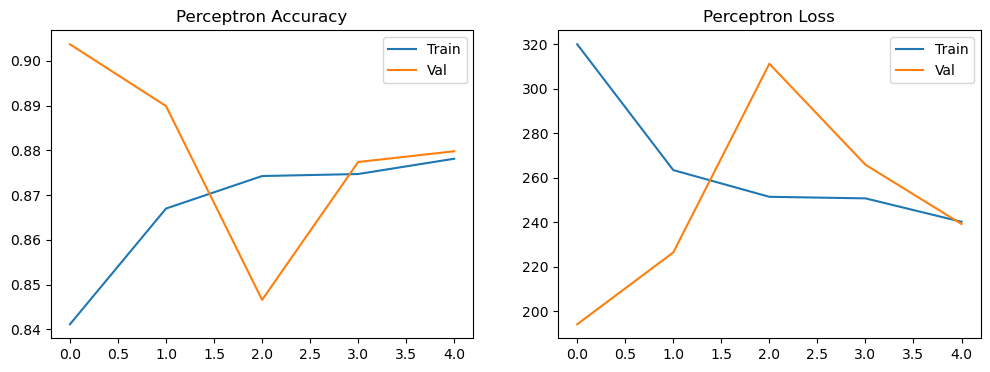

In [63]:
plot_training(history_perc,'Perceptron')

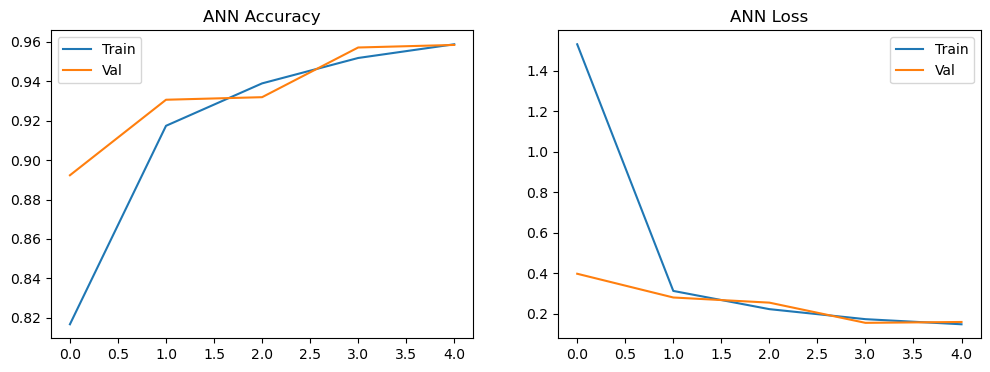

In [64]:
plot_training(history_ann,'ANN')

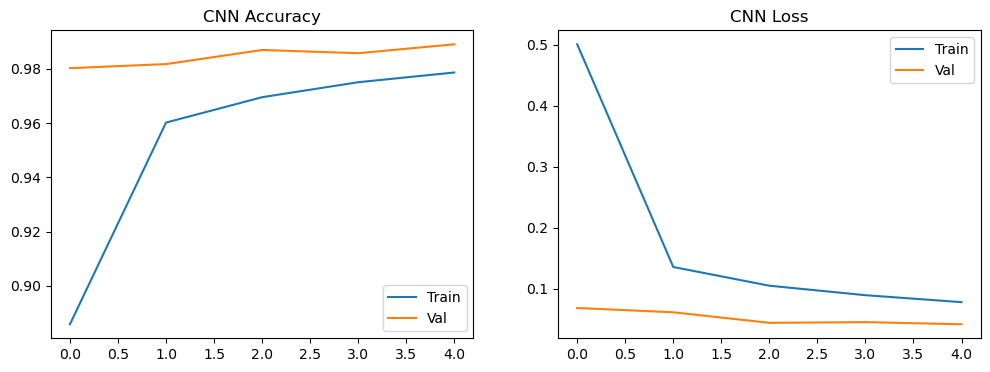

In [65]:
plot_training(history_cnn,'CNN')

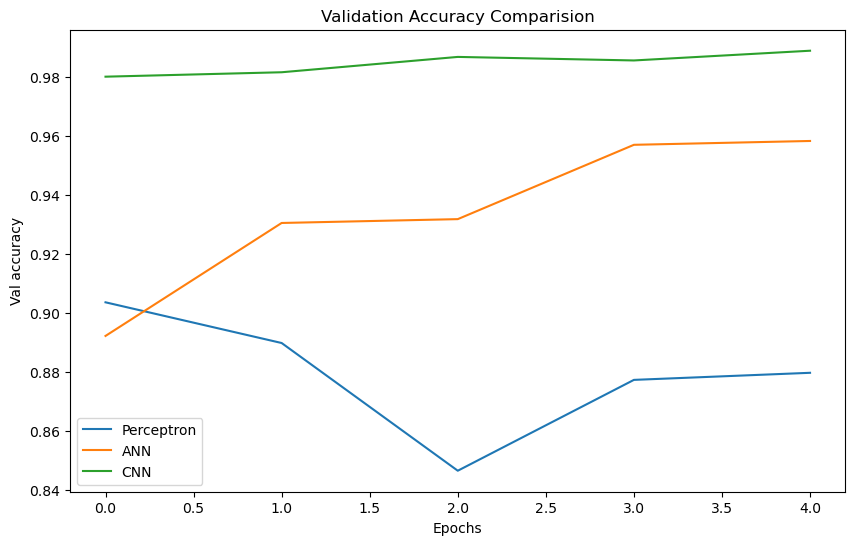

In [66]:
plt.figure(figsize=(10,6))
plt.plot(history_perc.history['val_accuracy'],label='Perceptron')
plt.plot(history_ann.history['val_accuracy'],label='ANN')
plt.plot(history_cnn.history['val_accuracy'],label='CNN')
plt.title('Validation Accuracy Comparision')
plt.xlabel('Epochs')
plt.ylabel('Val accuracy')
plt.legend()
plt.show()

In [67]:
def show_side_by_side(models,model_names,X,X_cnn,y_true,n=5):
    idxs = np.random.choice(len(X),n,replace=False)
    plt.figure(figsize=(15,6))
    for i,idx in enumerate(idxs):
        plt.subplot(2,n,i+1)
        plt.imshow(X[idx].reshape(28,28),cmap='gray')
        plt.axis('off')
        plt.title(f'True:{y_true[idx]}')
        preds = [np.argmax(model.predict(X_cnn[idx].reshape(1,28,28,1) if name == 'CNN' else X[idx].reshape(1,28,28)))
                for model,name in zip(models,model_names)]
        plt.subplot(2,n,n+i+1)
        plt.axis('off')
        plt.title('\n'.join(f'{n}:{p}' for n,p in zip(model_names,preds)))
    plt.tight_layout()
    plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 90ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 71ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 65ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 69ms/step


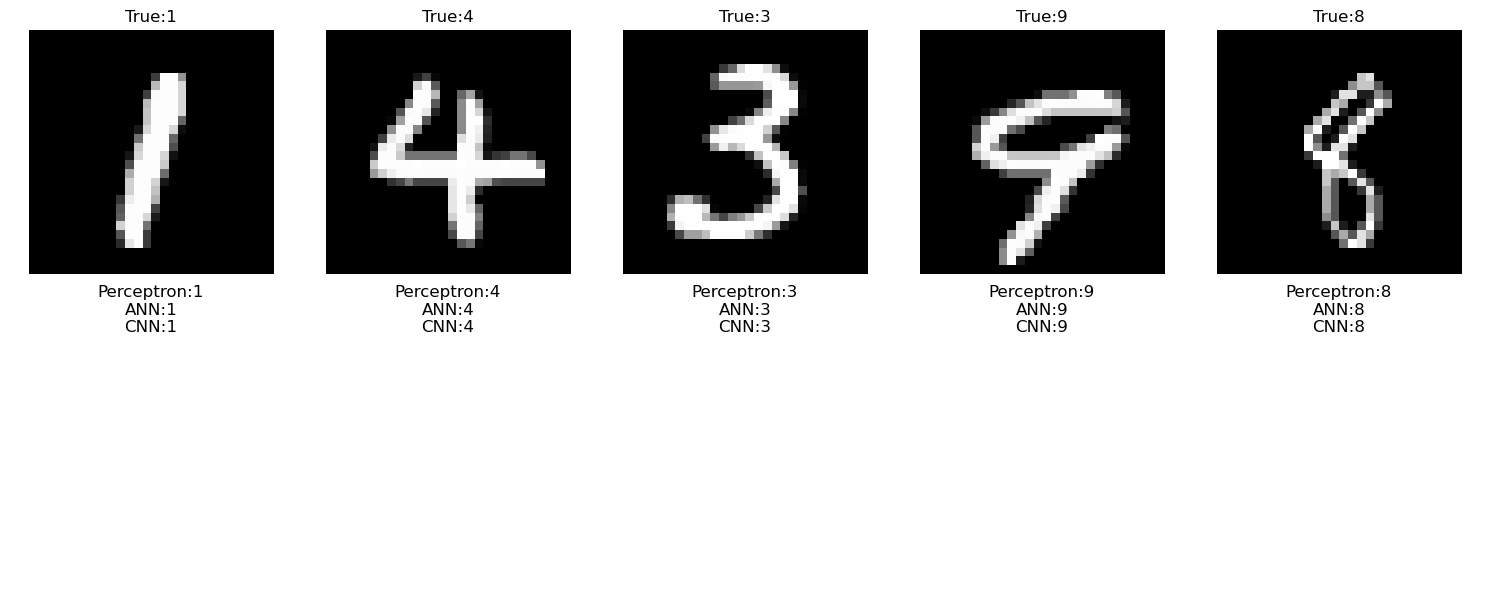

In [69]:
show_side_by_side([perceptron,ann,cnn],['Perceptron','ANN','CNN'],x_test_img,x_test_cnn,y_test,5)

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step


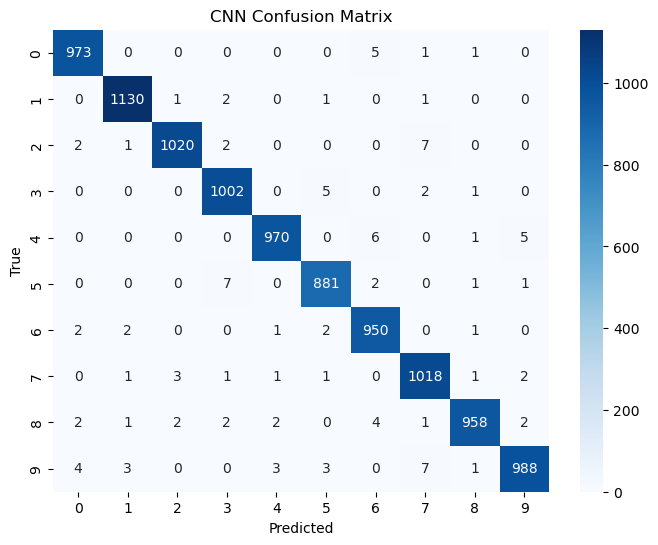

In [70]:
y_pred_cnn = np.argmax(cnn.predict(x_test_cnn),axis=1)
cm = confusion_matrix(y_test,y_pred_cnn)
plt.figure(figsize=(8,6))
sns.heatmap(cm,annot=True,fmt='d',cmap='Blues')
plt.title('CNN Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

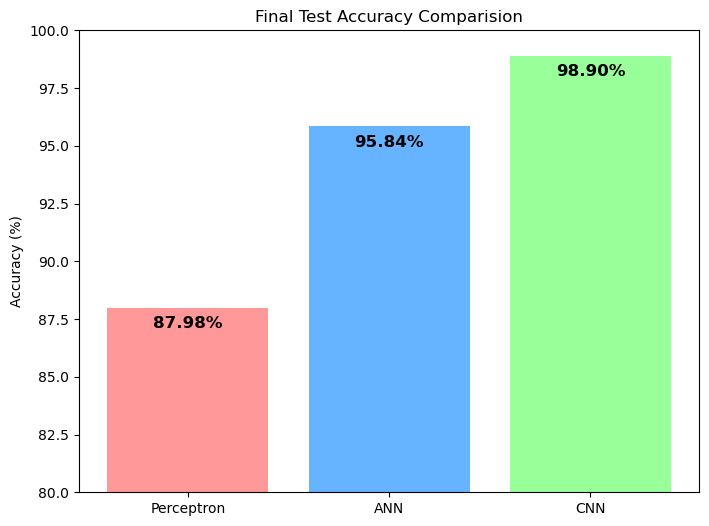

In [75]:
final_accs = [acc_perc*100,acc_ann*100,acc_cnn*100]
models = ['Perceptron','ANN','CNN']

plt.figure(figsize=(8,6))
bars = plt.bar(models,final_accs,color=['#ff9999','#66b3ff','#99ff99'])
plt.title('Final Test Accuracy Comparision')
plt.ylabel('Accuracy (%)')
for bar, acc in zip (bars,final_accs):
    plt.text(bar.get_x()+bar.get_width()/2,
            bar.get_height()-1,
            f'{acc:.2f}%',
            ha='center',
            va='bottom',
            fontsize=12,
            fontweight='bold')
plt.ylim(80,100)
plt.show()